# IT2011 Artificial Intelligence and Machine Learning
## Customer Churn Prediction
### Combined Group Data Preprocessing Pipeline

This notebook integrates all six individual preprocessing contributions into one complete preprocessing workflow for the **Bank Customer Churn** dataset.

### Group Member Contributions

- **Lathurshan** — Handling Missing Values and Duplicate Values
- **Aathmika** — Encoding Categorical Variables
- **Shakeer** — Outlier Detection and Removal
- **Sipna** — Class Imbalance Handling
- **Thishan** — Feature Engineering
- **Fatheen** — Standardization and Scaling

### Combined Pipeline Flow

1. Load the original `Churn_Modelling.csv` dataset
2. Handle missing values and duplicate records
3. Encode categorical variables
4. Detect and remove outliers
5. Handle class imbalance
6. Create engineered features
7. Standardize numerical features
8. Perform final validation
9. Save the final processed dataset

Each preprocessing stage contains an EDA/visualization checkpoint.


In [ ]:
# ============================================================
# GROUP SETUP - Common Libraries
# ============================================================

import sys
import subprocess
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Install imbalanced-learn only if required
if importlib.util.find_spec("imblearn") is None:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "imbalanced-learn"]
    )

from imblearn.over_sampling import RandomOverSampler

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Libraries imported successfully!")


Libraries imported successfully!


## Load the Original Dataset

The combined notebook always starts from the **original dataset**, so it does not depend on the CSV outputs of the six separate notebooks.

For Google Colab, upload `Churn_Modelling.csv` if it is not already available in `/content/`.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling.csv


In [ ]:
# ============================================================
# GROUP SETUP - Load Original Dataset
# ============================================================

possible_paths = [
    Path("/content/Churn_Modelling.csv"),
    Path("Churn_Modelling.csv")
]

file_path = None

for path in possible_paths:
    if path.exists():
        file_path = path
        break

if file_path is None:
    try:
        from google.colab import files
        uploaded = files.upload()

        if "Churn_Modelling.csv" not in uploaded:
            raise FileNotFoundError(
                "Please upload the file with the name Churn_Modelling.csv"
            )

        file_path = Path("/content/Churn_Modelling.csv")

    except ImportError:
        raise FileNotFoundError(
            "Churn_Modelling.csv was not found. "
            "Place it in the same folder as this notebook."
        )

df_original = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Loaded file:", file_path)
print("Dataset shape:", df_original.shape)

df_original.head()


Dataset loaded successfully!
Loaded file: /content/Churn_Modelling.csv
Dataset shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# ============================================================
# GROUP SETUP - Initial Dataset Information
# ============================================================

print("Dataset Information")
print("=" * 60)
df_original.info()

print("\nOriginal shape:", df_original.shape)
print("Original missing values:", df_original.isnull().sum().sum())
print("Original duplicate rows:", df_original.duplicated().sum())

display(df_original.describe(include="all").T)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

Original shape: (10000, 14)
Original missing values: 0
Original duplicate

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


# 1. Missing Value and Duplicate Handling
### Lathurshan

This section checks the original dataset for:

- missing values
- duplicate records

### Cleaning strategy

- Numerical missing values → **Median**
- Categorical missing values → **Mode**
- Fully duplicated rows → **Removed**

The code is reusable even if the current dataset contains no missing or duplicate records.


In [ ]:
# ============================================================
# 1A - Missing Value Summary Before Cleaning
# ============================================================

missing_before = df_original.isnull().sum()

missing_table = pd.DataFrame({
    "Column": missing_before.index,
    "Missing Values": missing_before.values,
    "Missing Percentage": (
        missing_before.values / len(df_original) * 100
    )
})

display(missing_table)


,Column,Missing Values,Missing Percentage
0,RowNumber,0,0.0
1,CustomerId,0,0.0
2,Surname,0,0.0
3,CreditScore,0,0.0
4,Geography,0,0.0
5,Gender,0,0.0
6,Age,0,0.0
7,Tenure,0,0.0
8,Balance,0,0.0
9,NumOfProducts,0,0.0


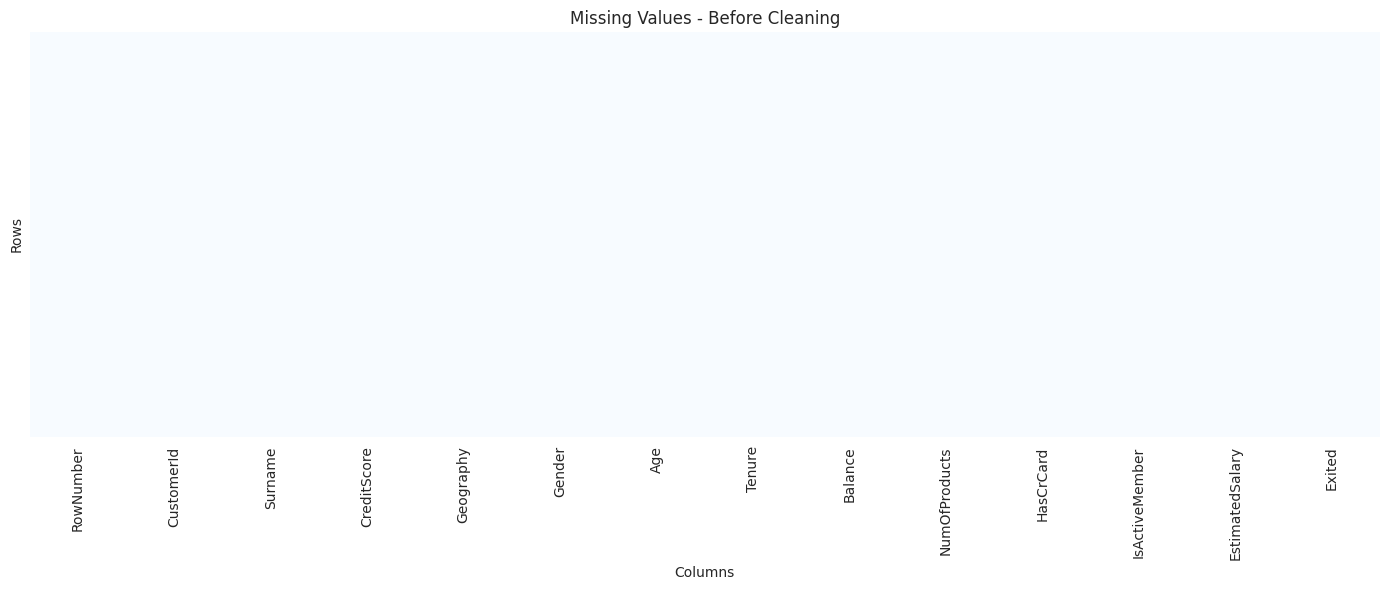

In [ ]:
# ============================================================
# 1B - Missing Value Visualization
# ============================================================

plt.figure(figsize=(14, 6))

sns.heatmap(
    df_original.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="Blues"
)

plt.title("Missing Values - Before Cleaning")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()


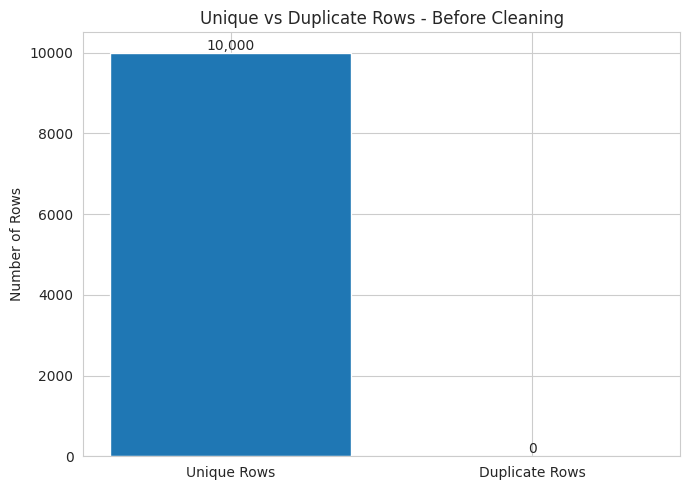

In [ ]:
# ============================================================
# 1C - Duplicate Visualization
# ============================================================

duplicate_before = df_original.duplicated().sum()
unique_before = len(df_original) - duplicate_before

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["Unique Rows", "Duplicate Rows"],
    [unique_before, duplicate_before]
)

plt.title("Unique vs Duplicate Rows - Before Cleaning")
plt.ylabel("Number of Rows")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 1D - Handle Missing Values and Duplicates
# ============================================================

df_cleaned = df_original.copy()

numeric_cols_initial = df_cleaned.select_dtypes(
    include=np.number
).columns

categorical_cols_initial = df_cleaned.select_dtypes(
    exclude=np.number
).columns

# Numerical columns -> median
for col in numeric_cols_initial:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col] = df_cleaned[col].fillna(
            df_cleaned[col].median()
        )

# Categorical columns -> mode
for col in categorical_cols_initial:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col] = df_cleaned[col].fillna(
            df_cleaned[col].mode()[0]
        )

# Remove full duplicate rows
rows_before_duplicate_removal = len(df_cleaned)

df_cleaned = (
    df_cleaned
    .drop_duplicates()
    .reset_index(drop=True)
)

print(
    "Missing values before:",
    df_original.isnull().sum().sum()
)

print(
    "Missing values after :",
    df_cleaned.isnull().sum().sum()
)

print(
    "Duplicate rows removed:",
    rows_before_duplicate_removal - len(df_cleaned)
)

print("Shape after Stage 1:", df_cleaned.shape)


Missing values before: 0
Missing values after : 0
Duplicate rows removed: 0
Shape after Stage 1: (10000, 14)


### EDA Interpretation — Missing Values and Duplicates

This stage ensures that incomplete records and accidental duplicate records do not affect later preprocessing.

For the provided churn dataset, the code will report the actual number of missing values and duplicates at runtime. If none are present, the dataset remains unchanged at this stage.


# 2. Categorical Encoding
### Aathmika

This section prepares categorical information for machine learning.

### Identifier columns removed

- `RowNumber`
- `CustomerId`
- `Surname`

These columns identify individual records but do not represent meaningful predictive customer characteristics.

### Encoding strategy

- `Gender`: Female = 0, Male = 1
- `Geography`: One-Hot Encoding with one reference category removed using `drop_first=True`


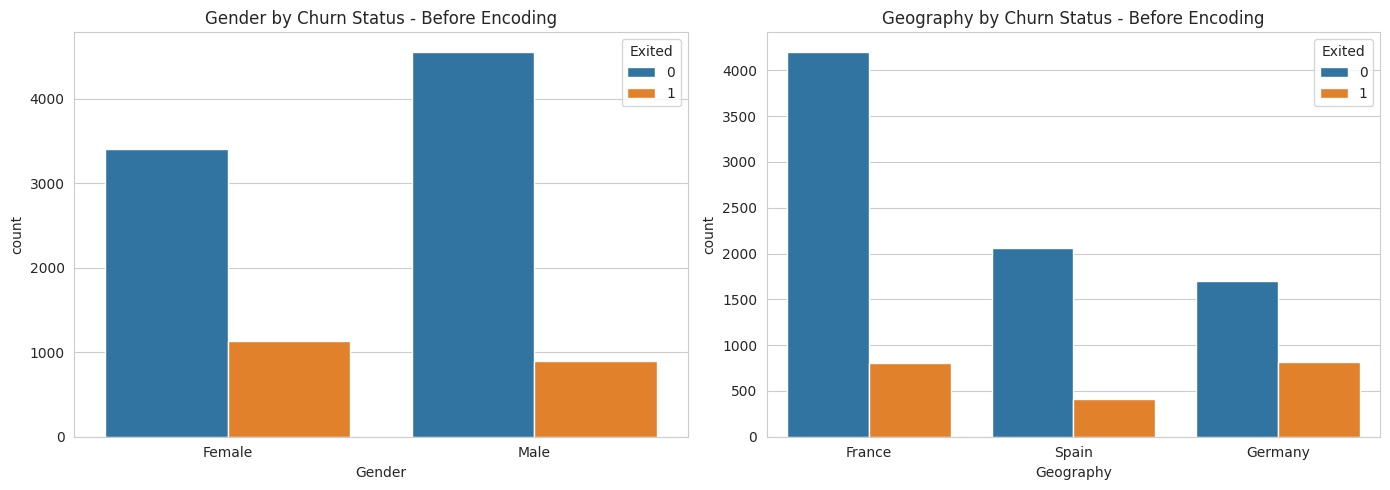

In [ ]:
# ============================================================
# 2A - Categorical EDA Before Encoding
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=df_cleaned,
    x="Gender",
    hue="Exited",
    ax=axes[0]
)
axes[0].set_title("Gender by Churn Status - Before Encoding")
axes[0].set_xlabel("Gender")

sns.countplot(
    data=df_cleaned,
    x="Geography",
    hue="Exited",
    ax=axes[1]
)
axes[1].set_title("Geography by Churn Status - Before Encoding")
axes[1].set_xlabel("Geography")

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 2B - Remove Identifier Columns
# ============================================================

df_encoded = df_cleaned.copy()

identifier_columns = [
    "RowNumber",
    "CustomerId",
    "Surname"
]

df_encoded = df_encoded.drop(
    columns=identifier_columns,
    errors="ignore"
)

print("Removed identifier columns:")
print(identifier_columns)

print("\nRemaining columns:")
print(df_encoded.columns.tolist())


Removed identifier columns:
['RowNumber', 'CustomerId', 'Surname']

Remaining columns:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [ ]:
# ============================================================
# 2C - Encode Gender and Geography
# ============================================================

# Binary encoding
gender_mapping = {
    "Female": 0,
    "Male": 1
}

df_encoded["Gender"] = (
    df_encoded["Gender"]
    .map(gender_mapping)
)

# One-Hot Encoding for nominal Geography
df_encoded = pd.get_dummies(
    df_encoded,
    columns=["Geography"],
    drop_first=True,
    dtype=int
)

print("Categorical encoding completed.")
print("Shape after Stage 2:", df_encoded.shape)

df_encoded.head()


Categorical encoding completed.
Shape after Stage 2: (10000, 12)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


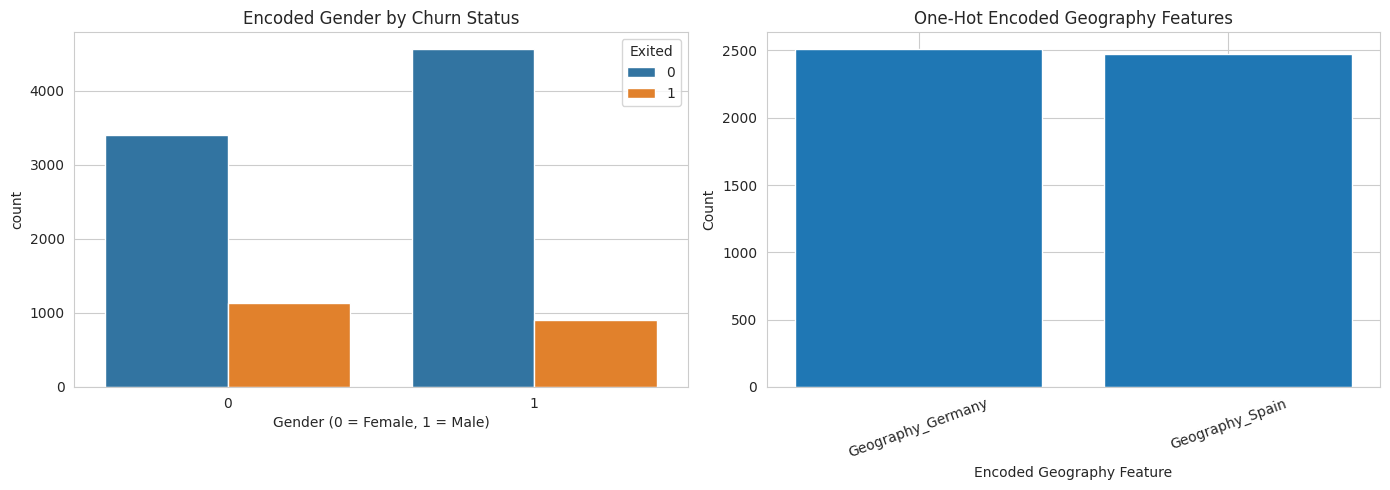

In [ ]:
# ============================================================
# 2D - EDA After Encoding
# ============================================================

geo_dummy_cols = [
    col for col in df_encoded.columns
    if col.startswith("Geography_")
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=df_encoded,
    x="Gender",
    hue="Exited",
    ax=axes[0]
)
axes[0].set_title("Encoded Gender by Churn Status")
axes[0].set_xlabel("Gender (0 = Female, 1 = Male)")

geo_counts = df_encoded[geo_dummy_cols].sum()

axes[1].bar(
    geo_counts.index.astype(str),
    geo_counts.values
)
axes[1].set_title("One-Hot Encoded Geography Features")
axes[1].set_xlabel("Encoded Geography Feature")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


### EDA Interpretation — Encoding

The categorical plots allow us to compare customer groups before encoding.

After encoding, all model predictors are represented numerically. `Gender` becomes a binary variable and `Geography` becomes dummy variables, allowing machine-learning algorithms to use these categories without assuming an incorrect numerical order.


# 3. Outlier Detection and Removal
### Shakeer

This section uses the **Interquartile Range (IQR)** method.

### Features checked

- `CreditScore`
- `Age`
- `Tenure`
- `Balance`
- `NumOfProducts`
- `EstimatedSalary`

Binary variables, dummy variables and the target are excluded from IQR-based outlier removal.


In [ ]:
# ============================================================
# 3A - Select Numerical Features for IQR Analysis
# ============================================================

outlier_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

outlier_features = [
    col for col in outlier_features
    if col in df_encoded.columns
]

print("Features used for outlier detection:")
print(outlier_features)


Features used for outlier detection:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']


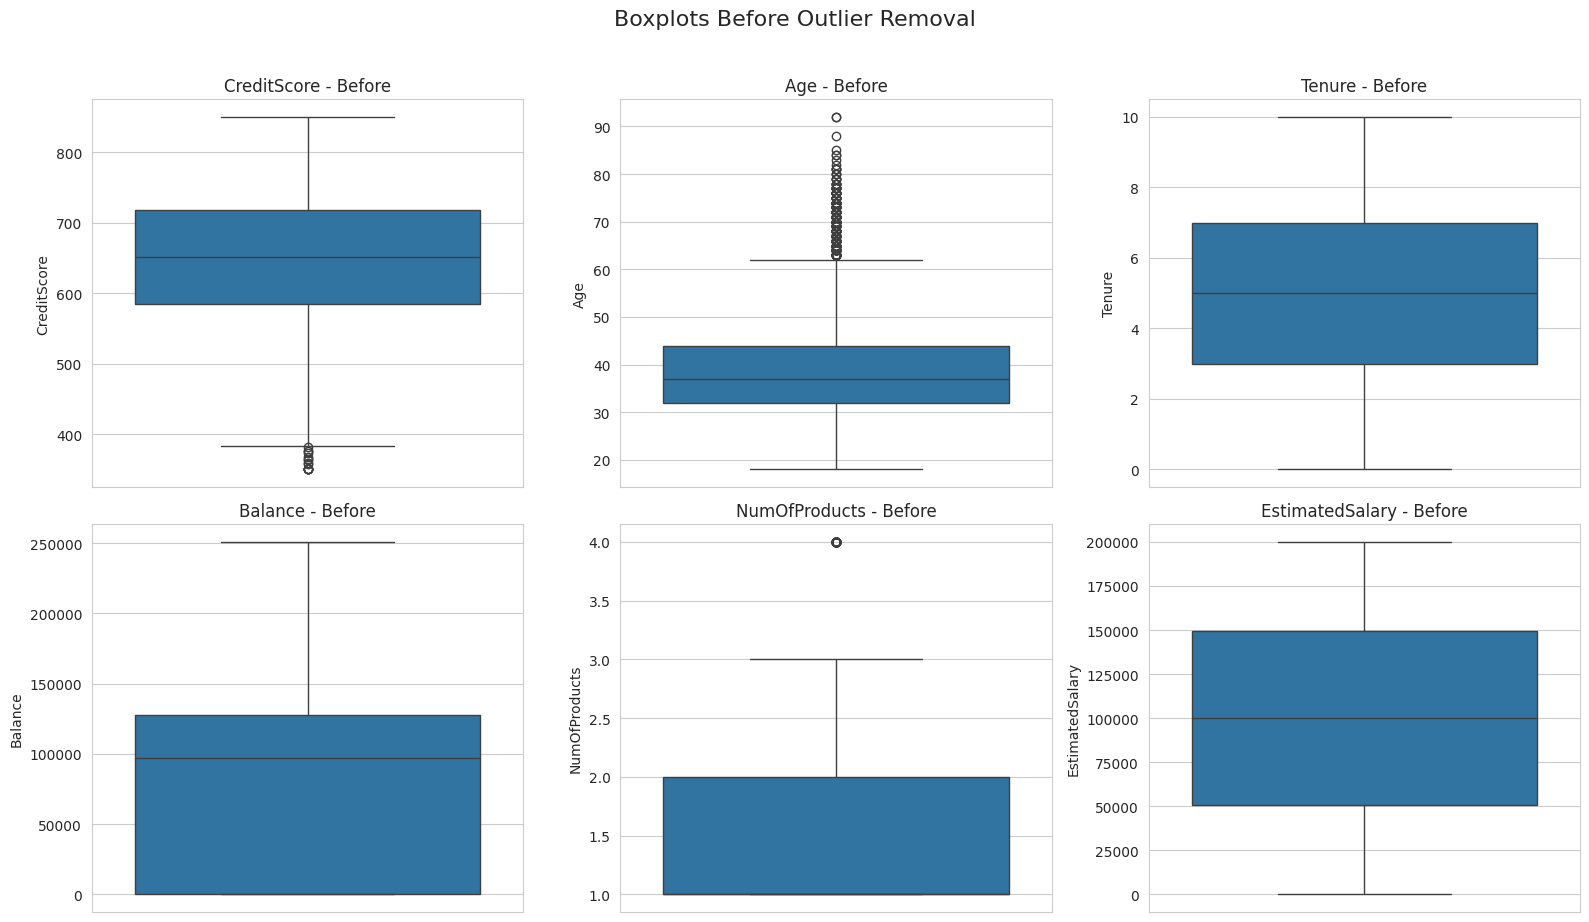

In [ ]:
# ============================================================
# 3B - Boxplots Before Outlier Removal
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(outlier_features):
    sns.boxplot(
        data=df_encoded,
        y=col,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} - Before")

for j in range(len(outlier_features), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Boxplots Before Outlier Removal",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 3C - Calculate IQR Bounds and Outlier Counts
# ============================================================

outlier_summary = []
combined_outlier_mask = pd.Series(
    False,
    index=df_encoded.index
)

outlier_bounds = {}

for col in outlier_features:

    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    current_mask = (
        (df_encoded[col] < lower_bound) |
        (df_encoded[col] > upper_bound)
    )

    combined_outlier_mask |= current_mask

    outlier_bounds[col] = {
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound
    }

    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": int(current_mask.sum())
    })

outlier_summary_df = pd.DataFrame(
    outlier_summary
)

display(outlier_summary_df)


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,CreditScore,584.00,718.0000,134.0000,383.00000,919.00000,15
1,Age,32.00,44.0000,12.0000,14.00000,62.00000,359
2,Tenure,3.00,7.0000,4.0000,-3.00000,13.00000,0
3,Balance,0.00,127644.2400,127644.2400,-191466.36000,319110.60000,0
4,NumOfProducts,1.00,2.0000,1.0000,-0.50000,3.50000,60
5,EstimatedSalary,51002.11,149388.2475,98386.1375,-96577.09625,296967.45375,0


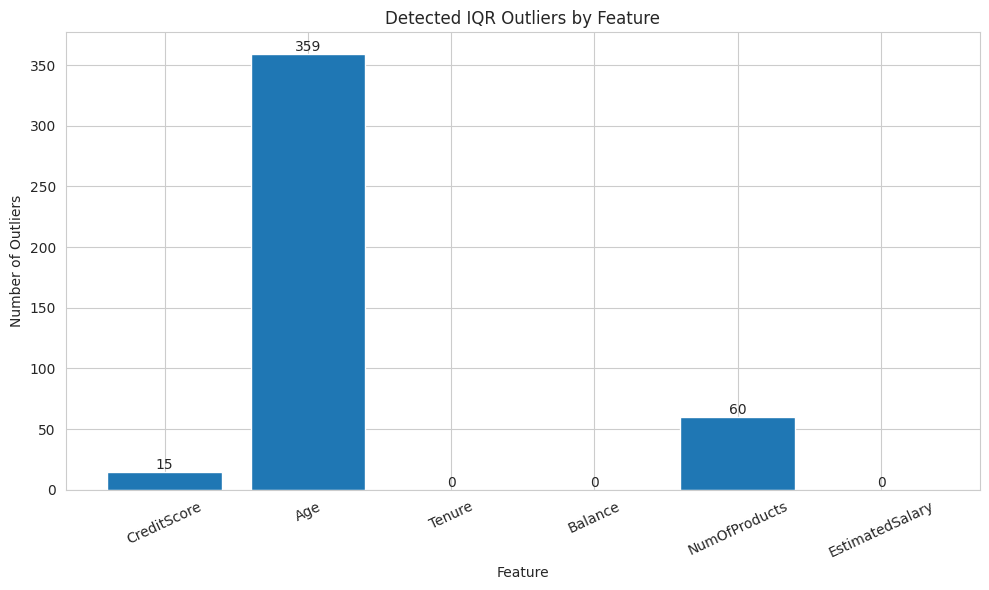

In [ ]:
# ============================================================
# 3D - Visualize Outlier Counts
# ============================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    outlier_summary_df["Feature"].astype(str),
    outlier_summary_df["Outlier Count"]
)

plt.title("Detected IQR Outliers by Feature")
plt.xlabel("Feature")
plt.ylabel("Number of Outliers")
plt.xticks(rotation=25)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 3E - Remove Rows Containing Detected Outliers
# ============================================================

rows_before_outlier_removal = len(df_encoded)

df_outlier = (
    df_encoded
    .loc[~combined_outlier_mask]
    .copy()
    .reset_index(drop=True)
)

rows_removed = (
    rows_before_outlier_removal -
    len(df_outlier)
)

print("Rows before outlier removal:", rows_before_outlier_removal)
print("Rows removed               :", rows_removed)
print("Rows after outlier removal :", len(df_outlier))
print(
    "Percentage removed         :",
    f"{rows_removed / rows_before_outlier_removal * 100:.2f}%"
)

print("Shape after Stage 3:", df_outlier.shape)


Rows before outlier removal: 10000
Rows removed               : 432
Rows after outlier removal : 9568
Percentage removed         : 4.32%
Shape after Stage 3: (9568, 12)


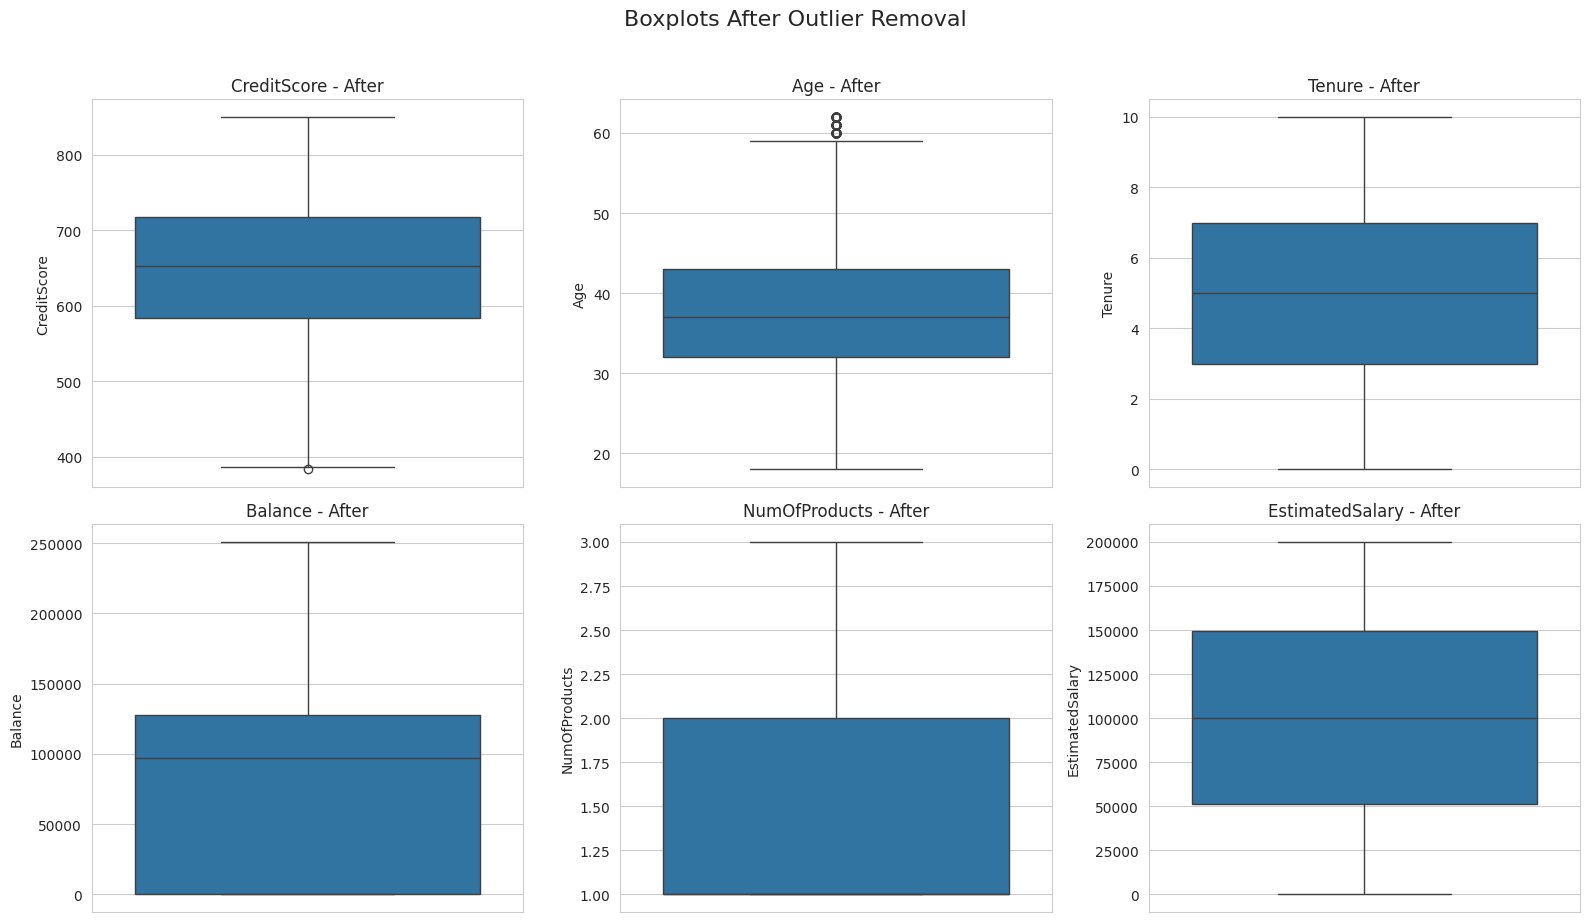

In [ ]:
# ============================================================
# 3F - Boxplots After Outlier Removal
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(outlier_features):
    sns.boxplot(
        data=df_outlier,
        y=col,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} - After")

for j in range(len(outlier_features), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Boxplots After Outlier Removal",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()


### Outlier Analysis Interpretation

The IQR method identifies observations lying below `Q1 - 1.5 × IQR` or above `Q3 + 1.5 × IQR`.

Only suitable numerical predictors are analyzed. Binary and one-hot encoded features are excluded because values such as 0 and 1 are valid categories rather than numerical outliers.


# 4. Class Imbalance Handling
### Sipna

The churn target usually contains more customers who stayed (`Exited = 0`) than customers who churned (`Exited = 1`).

This section uses **Random Oversampling** to increase the minority class until both classes contain the same number of records.

Random Oversampling is suitable for this sequential demonstration because it duplicates existing minority-class rows and therefore preserves valid 0/1 encoded values.


,Class,Count,Percentage
0,0,7677,80.24
1,1,1891,19.76


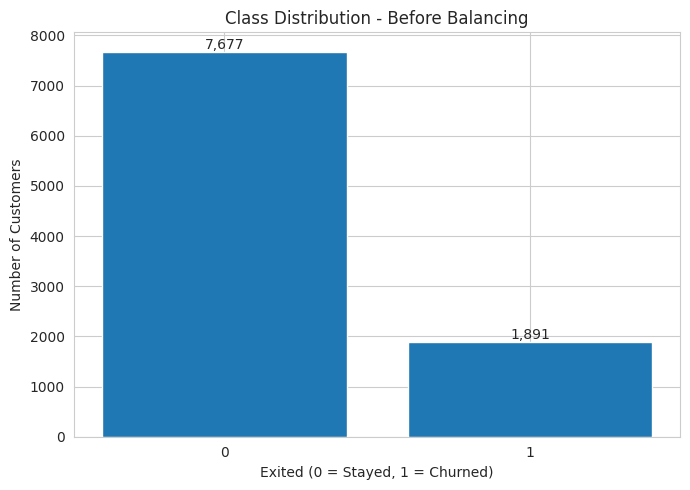

In [ ]:
# ============================================================
# 4A - Target Distribution Before Balancing
# ============================================================

class_counts_before = (
    df_outlier["Exited"]
    .value_counts()
    .sort_index()
)

class_percent_before = (
    df_outlier["Exited"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

class_summary_before = pd.DataFrame({
    "Class": class_counts_before.index,
    "Count": class_counts_before.values,
    "Percentage": class_percent_before.values
})

display(class_summary_before.round(2))

plt.figure(figsize=(7, 5))

bars = plt.bar(
    class_counts_before.index.astype(str),
    class_counts_before.values
)

plt.title("Class Distribution - Before Balancing")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 4B - Imbalance Ratio
# ============================================================

majority_count = class_counts_before.max()
minority_count = class_counts_before.min()

imbalance_ratio = (
    majority_count / minority_count
)

print("Majority class count:", majority_count)
print("Minority class count:", minority_count)
print(f"Imbalance ratio: {imbalance_ratio:.2f} : 1")


Majority class count: 7677
Minority class count: 1891
Imbalance ratio: 4.06 : 1


In [ ]:
# ============================================================
# 4C - Apply Random Oversampling
# ============================================================

X_before_balance = df_outlier.drop(
    columns=["Exited"]
)

y_before_balance = df_outlier["Exited"]

ros = RandomOverSampler(
    random_state=RANDOM_STATE
)

X_balanced, y_balanced = ros.fit_resample(
    X_before_balance,
    y_before_balance
)

df_balanced = X_balanced.copy()
df_balanced["Exited"] = y_balanced.values

print("Shape before balancing:", df_outlier.shape)
print("Shape after balancing :", df_balanced.shape)

print("\nClass distribution after balancing:")
print(
    df_balanced["Exited"]
    .value_counts()
    .sort_index()
)


Shape before balancing: (9568, 12)
Shape after balancing : (15354, 12)

Class distribution after balancing:
Exited
0    7677
1    7677
Name: count, dtype: int64


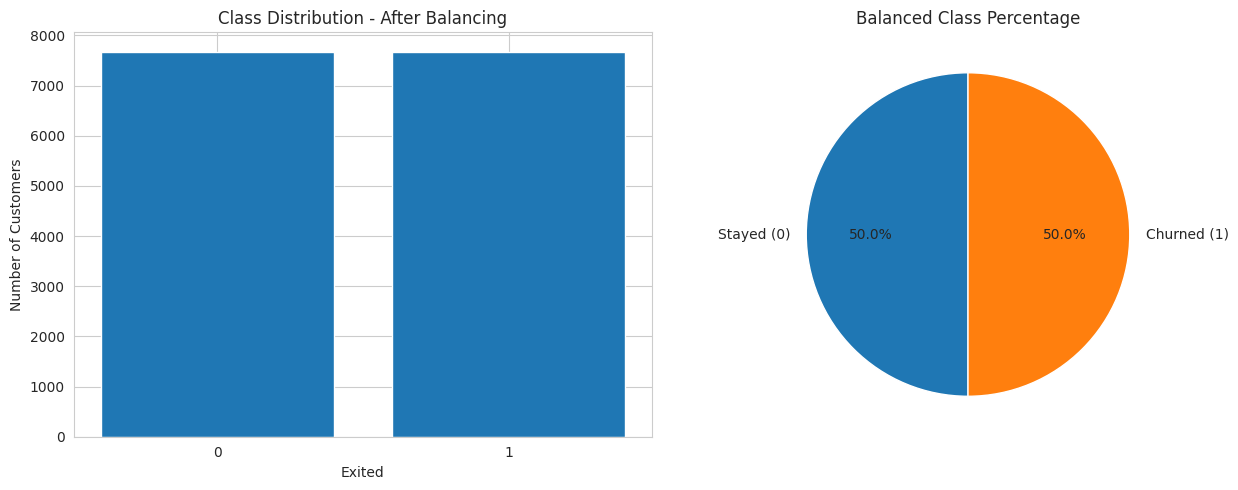

In [ ]:
# ============================================================
# 4D - EDA After Balancing
# ============================================================

class_counts_after = (
    df_balanced["Exited"]
    .value_counts()
    .sort_index()
)

class_percent_after = (
    df_balanced["Exited"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(
    class_counts_after.index.astype(str),
    class_counts_after.values
)
axes[0].set_title("Class Distribution - After Balancing")
axes[0].set_xlabel("Exited")
axes[0].set_ylabel("Number of Customers")

axes[1].pie(
    class_counts_after.values,
    labels=["Stayed (0)", "Churned (1)"],
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Balanced Class Percentage")

plt.tight_layout()
plt.show()


### Class Imbalance Interpretation

Before balancing, the majority class contains substantially more observations than the minority class.

After Random Oversampling, both target classes contain the same number of records. Because this method duplicates existing minority observations, duplicate rows in the balanced dataset are **expected and intentional**.

> **Important for final model evaluation:** oversampling should be applied only to the training set after the train/test split. A leakage-safe example is included near the end of this notebook.


# 5. Feature Engineering
### Thishan

This section creates six new features from existing predictors.

### Engineered Features

1. `BalanceSalaryRatio`
2. `TenureByAge`
3. `BalancePerProduct`
4. `ProductsPerTenure`
5. `ActiveWithCard`
6. `IsZeroBalance`

The target `Exited` is not used to create any new predictor, preventing target leakage.


In [ ]:
# ============================================================
# 5A - Create a Feature-Engineering Copy
# ============================================================

df_featured = df_balanced.copy()

print("Shape before feature engineering:", df_featured.shape)


Shape before feature engineering: (15354, 12)


In [ ]:
# ============================================================
# 5B - Create Engineered Features
# ============================================================

# 1. Balance relative to estimated salary
salary_safe = (
    df_featured["EstimatedSalary"]
    .replace(0, np.nan)
)

df_featured["BalanceSalaryRatio"] = (
    df_featured["Balance"] / salary_safe
).replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

# 2. Tenure relative to age
age_safe = (
    df_featured["Age"]
    .replace(0, np.nan)
)

df_featured["TenureByAge"] = (
    df_featured["Tenure"] / age_safe
).replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

# 3. Balance per bank product
products_safe = (
    df_featured["NumOfProducts"]
    .replace(0, np.nan)
)

df_featured["BalancePerProduct"] = (
    df_featured["Balance"] / products_safe
).replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

# 4. Product usage relative to tenure
df_featured["ProductsPerTenure"] = (
    df_featured["NumOfProducts"] /
    (df_featured["Tenure"] + 1)
)

# 5. Interaction between active membership and credit-card ownership
df_featured["ActiveWithCard"] = (
    df_featured["IsActiveMember"] *
    df_featured["HasCrCard"]
).astype(int)

# 6. Zero-balance indicator
df_featured["IsZeroBalance"] = (
    df_featured["Balance"] == 0
).astype(int)

engineered_features = [
    "BalanceSalaryRatio",
    "TenureByAge",
    "BalancePerProduct",
    "ProductsPerTenure",
    "ActiveWithCard",
    "IsZeroBalance"
]

print("Feature engineering completed.")
print("Shape after Stage 5:", df_featured.shape)

display(
    df_featured[
        engineered_features + ["Exited"]
    ].head()
)


Feature engineering completed.
Shape after Stage 5: (15354, 18)


,BalanceSalaryRatio,TenureByAge,BalancePerProduct,ProductsPerTenure,ActiveWithCard,IsZeroBalance,Exited
0,0.000000,0.047619,0.000000,0.333333,1,1,1
1,0.744677,0.024390,83807.860000,0.500000,0,0,0
2,1.401375,0.190476,53220.266667,0.333333,0,0,1
3,0.000000,0.025641,0.000000,1.000000,0,1,0
4,1.587055,0.046512,125510.820000,0.333333,1,0,0


In [ ]:
# ============================================================
# 5C - Validate Engineered Features
# ============================================================

print("Missing values in engineered features:")
print(
    df_featured[
        engineered_features
    ].isnull().sum()
)

print("\nInfinite values:")
print(
    np.isinf(
        df_featured[
            engineered_features
        ].select_dtypes(include=np.number)
    ).sum()
)


Missing values in engineered features:
BalanceSalaryRatio    0
TenureByAge           0
BalancePerProduct     0
ProductsPerTenure     0
ActiveWithCard        0
IsZeroBalance         0
dtype: int64

Infinite values:
BalanceSalaryRatio    0
TenureByAge           0
BalancePerProduct     0
ProductsPerTenure     0
ActiveWithCard        0
IsZeroBalance         0
dtype: int64


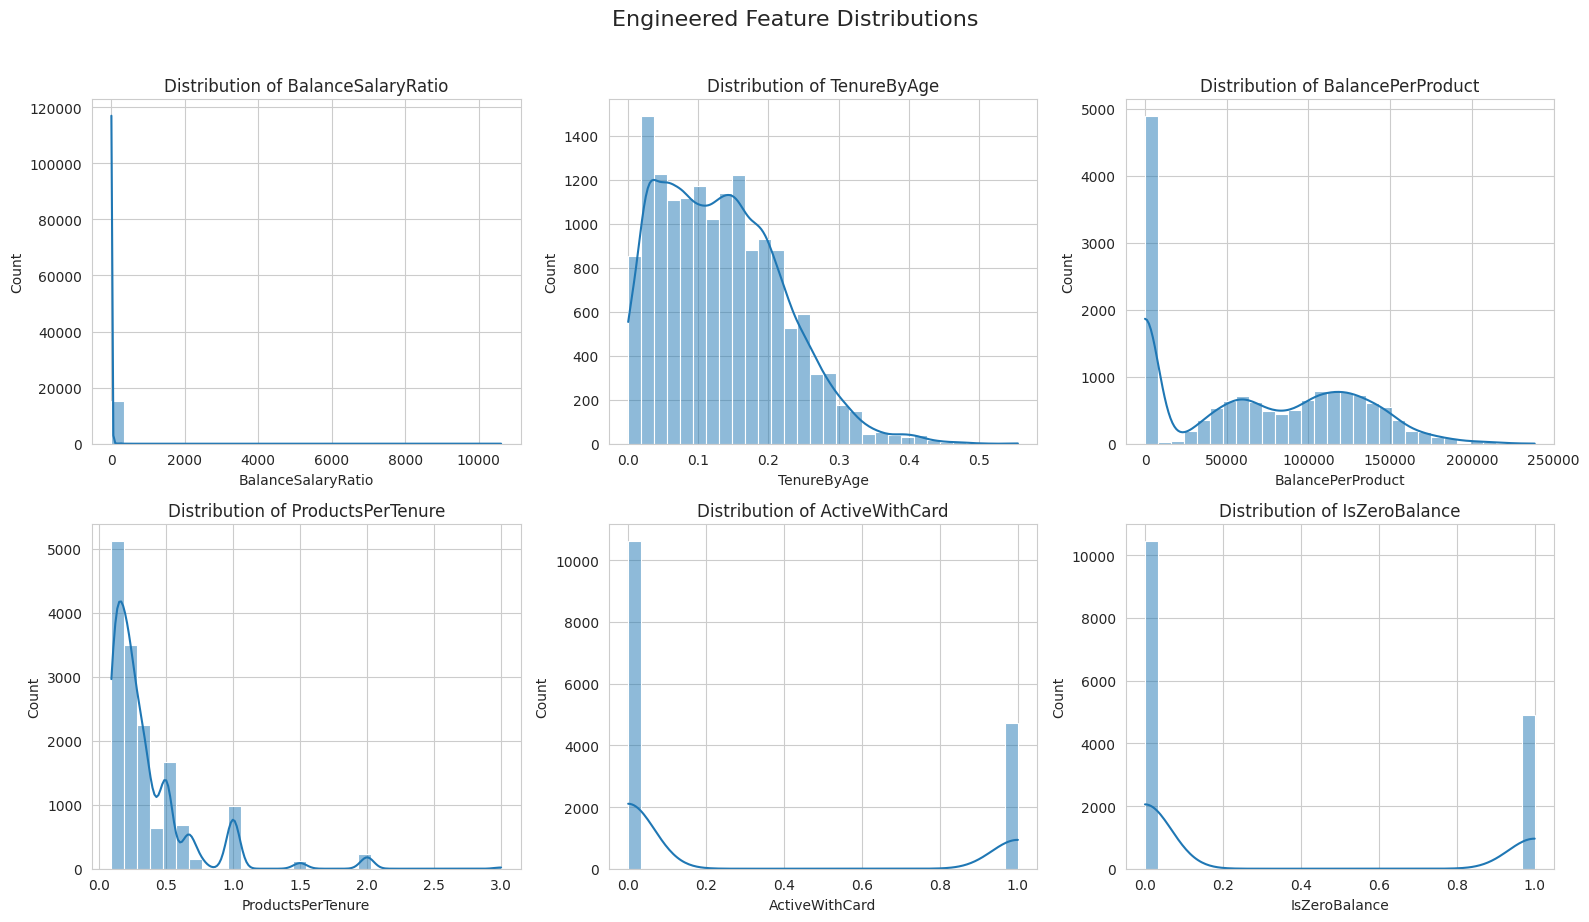

In [ ]:
# ============================================================
# 5D - EDA of Engineered Features
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(engineered_features):
    sns.histplot(
        data=df_featured,
        x=col,
        bins=30,
        kde=True,
        color="C0",
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {col}")

plt.suptitle(
    "Engineered Feature Distributions",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()


,Correlation with Exited
BalancePerProduct,0.149048
BalanceSalaryRatio,0.016781
ProductsPerTenure,-0.025703
IsZeroBalance,-0.154763
TenureByAge,-0.160460
ActiveWithCard,-0.160892


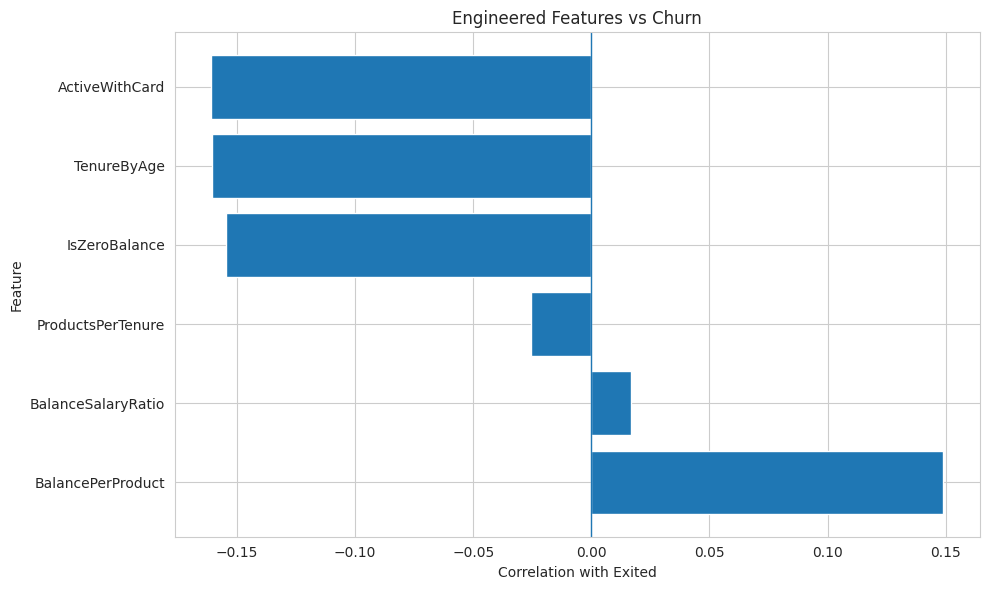

In [ ]:
# ============================================================
# 5E - Correlation of Engineered Features with Churn
# ============================================================

engineered_corr = (
    df_featured[
        engineered_features + ["Exited"]
    ]
    .corr()["Exited"]
    .drop("Exited")
    .sort_values(ascending=False)
)

display(
    engineered_corr.to_frame(
        name="Correlation with Exited"
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    engineered_corr.index.astype(str),
    engineered_corr.values
)

plt.axvline(0, linewidth=1)
plt.title("Engineered Features vs Churn")
plt.xlabel("Correlation with Exited")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


### Feature Engineering Interpretation

The engineered variables combine existing customer characteristics into more informative relationships, such as balance relative to salary and tenure relative to age.

Correlation is only one diagnostic. A weak linear correlation does not automatically mean an engineered feature is useless because many machine-learning models can learn non-linear effects and interactions.


# 6. Standardization and Scaling
### Fatheen

This section uses **StandardScaler** on continuous/count numerical predictors.

### Not scaled

- `Exited` — target
- `Gender`
- `HasCrCard`
- `IsActiveMember`
- `ActiveWithCard`
- `IsZeroBalance`
- `Geography_*`

Binary and dummy variables remain as 0/1 values.


In [ ]:
# ============================================================
# 6A - Select Features for Standardization
# ============================================================

scale_cols = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary",
    "BalanceSalaryRatio",
    "TenureByAge",
    "BalancePerProduct",
    "ProductsPerTenure"
]

scale_cols = [
    col for col in scale_cols
    if col in df_featured.columns
]

binary_dummy_cols = [
    col for col in df_featured.columns
    if (
        col in [
            "Gender",
            "HasCrCard",
            "IsActiveMember",
            "ActiveWithCard",
            "IsZeroBalance"
        ]
        or col.startswith("Geography_")
    )
]

print("Features selected for scaling:")
print(scale_cols)

print("\nBinary/dummy features kept unchanged:")
print(binary_dummy_cols)


Features selected for scaling:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'BalanceSalaryRatio', 'TenureByAge', 'BalancePerProduct', 'ProductsPerTenure']

Binary/dummy features kept unchanged:
['Gender', 'HasCrCard', 'IsActiveMember', 'Geography_Germany', 'Geography_Spain', 'ActiveWithCard', 'IsZeroBalance']


,Skewness
BalanceSalaryRatio,81.844943
ProductsPerTenure,2.984578
NumOfProducts,0.899430
TenureByAge,0.592056
Age,0.244655
BalancePerProduct,0.170937
Tenure,0.025407
EstimatedSalary,-0.003482
CreditScore,-0.047578
Balance,-0.268725


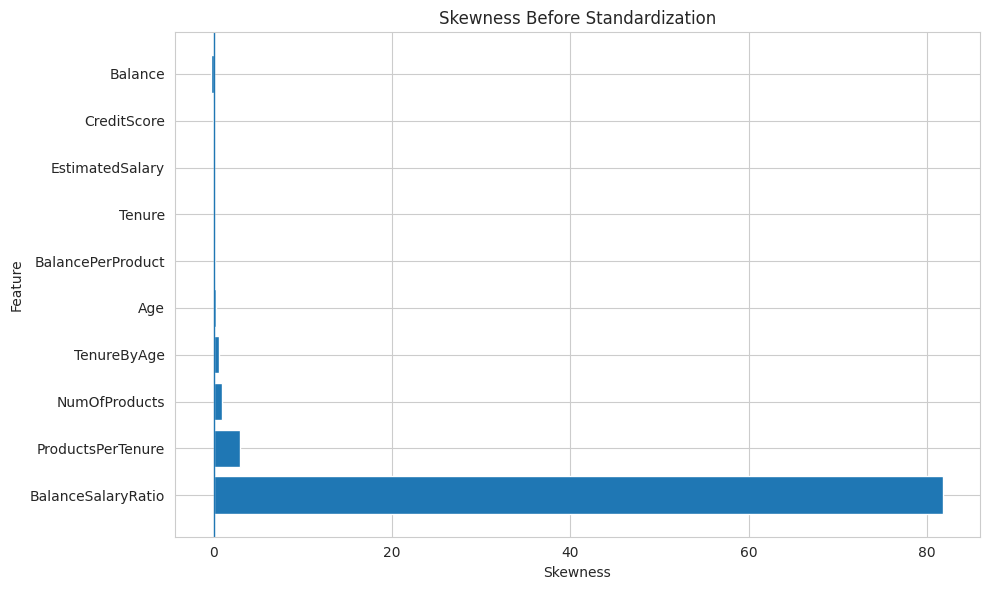

In [ ]:
# ============================================================
# 6B - Skewness Before Scaling
# ============================================================

skewness = (
    df_featured[scale_cols]
    .skew()
    .sort_values(ascending=False)
)

display(
    skewness.to_frame(
        name="Skewness"
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    skewness.index.astype(str),
    skewness.values
)

plt.axvline(0, linewidth=1)
plt.title("Skewness Before Standardization")
plt.xlabel("Skewness")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 6C - Apply StandardScaler
# ============================================================

df_final = df_featured.copy()

scaler = StandardScaler()

df_final[scale_cols] = scaler.fit_transform(
    df_featured[scale_cols]
)

print("Standardization completed.")
print("Shape after Stage 6:", df_final.shape)


Standardization completed.
Shape after Stage 6: (15354, 18)


In [ ]:
# ============================================================
# 6D - Verify Scaled Mean and Standard Deviation
# ============================================================

scaling_check = pd.DataFrame({
    "Mean": df_final[scale_cols].mean(),
    "Population Std": df_final[scale_cols].std(ddof=0)
})

display(
    scaling_check.round(6)
)


,Mean,Population Std
CreditScore,0.0,1.0
Age,-0.0,1.0
Tenure,-0.0,1.0
Balance,0.0,1.0
NumOfProducts,0.0,1.0
EstimatedSalary,0.0,1.0
BalanceSalaryRatio,0.0,1.0
TenureByAge,-0.0,1.0
BalancePerProduct,-0.0,1.0
ProductsPerTenure,-0.0,1.0


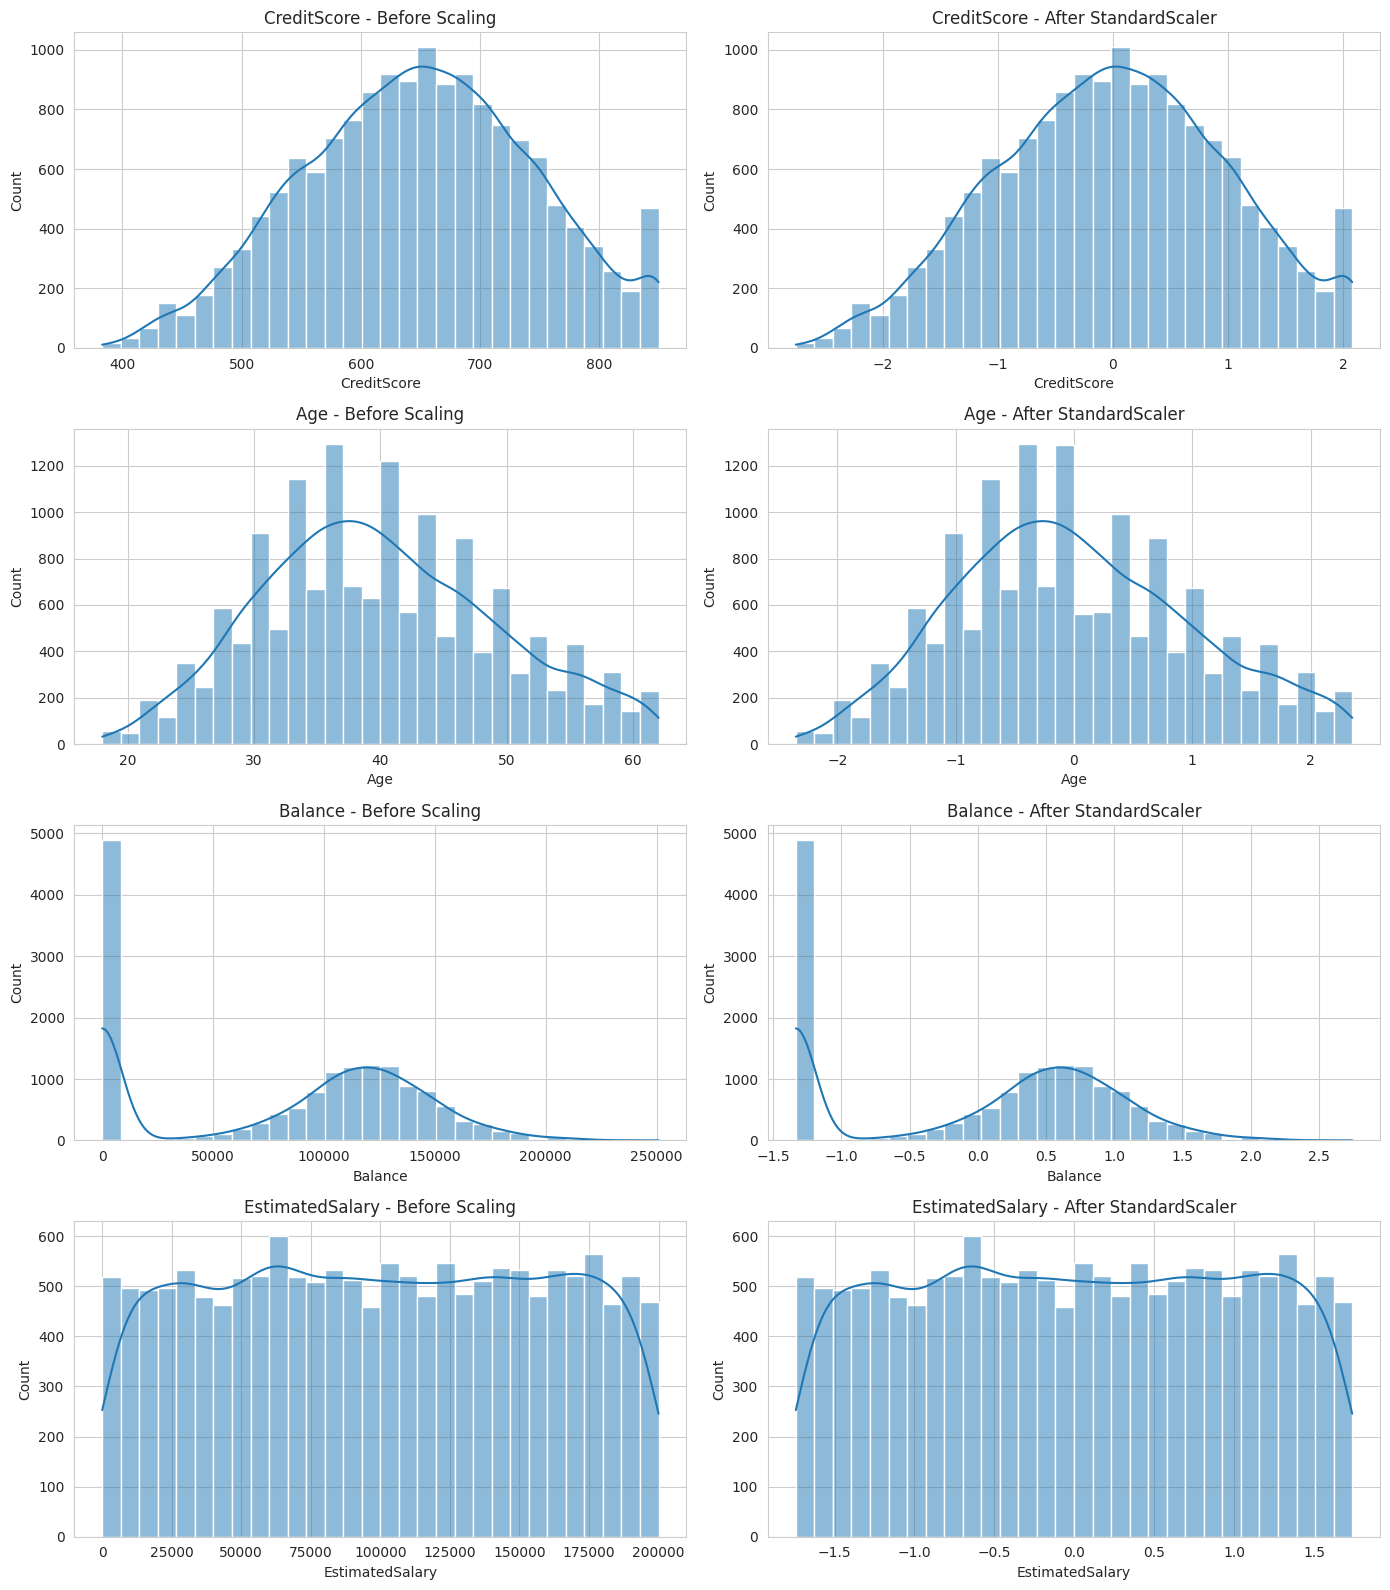

In [ ]:
# ============================================================
# 6E - EDA Before vs After Standardization
# ============================================================

comparison_features = [
    col for col in [
        "CreditScore",
        "Age",
        "Balance",
        "EstimatedSalary"
    ]
    if col in scale_cols
]

fig, axes = plt.subplots(
    len(comparison_features),
    2,
    figsize=(14, 4 * len(comparison_features))
)

if len(comparison_features) == 1:
    axes = np.array([axes])

for i, col in enumerate(comparison_features):

    sns.histplot(
        df_featured[col],
        bins=30,
        kde=True,
        color="C0",
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(
        f"{col} - Before Scaling"
    )

    sns.histplot(
        df_final[col],
        bins=30,
        kde=True,
        color="C0",
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(
        f"{col} - After StandardScaler"
    )

plt.tight_layout()
plt.show()


### Scaling Interpretation

After StandardScaler, the selected numerical variables are centered around zero and have population standard deviation approximately equal to one.

The transformation changes feature scale but preserves the basic shape and ordering of observations. Binary/dummy variables and the target remain unchanged.


# 7. Final Combined Pipeline Validation

This section confirms that the combined output is ready for downstream machine-learning work.


In [ ]:
# ============================================================
# 7A - Final Validation
# ============================================================

print("FINAL PIPELINE VALIDATION")
print("=" * 60)

print("Original dataset shape :", df_original.shape)
print("After cleaning         :", df_cleaned.shape)
print("After encoding         :", df_encoded.shape)
print("After outlier removal  :", df_outlier.shape)
print("After class balancing  :", df_balanced.shape)
print("After feature engineering:", df_featured.shape)
print("Final standardized shape:", df_final.shape)

print("\nFinal missing values:")
print(df_final.isnull().sum().sum())

print("\nFinal infinite numeric values:")
numeric_final = df_final.select_dtypes(include=np.number)

print(
    np.isinf(numeric_final.to_numpy()).sum()
)

print("\nFinal target distribution:")
print(
    df_final["Exited"]
    .value_counts()
    .sort_index()
)

print("\nAll predictor columns numeric:")
print(
    all(
        pd.api.types.is_numeric_dtype(
            df_final[col]
        )
        for col in df_final.columns
        if col != "Exited"
    )
)


FINAL PIPELINE VALIDATION
Original dataset shape : (10000, 14)
After cleaning         : (10000, 14)
After encoding         : (10000, 12)
After outlier removal  : (9568, 12)
After class balancing  : (15354, 12)
After feature engineering: (15354, 18)
Final standardized shape: (15354, 18)

Final missing values:
0

Final infinite numeric values:
0

Final target distribution:
Exited
0    7677
1    7677
Name: count, dtype: int64

All predictor columns numeric:
True


,Stage,Rows,Columns
0,Original,10000,14
1,Missing/Duplicate Handling,10000,14
2,Categorical Encoding,10000,12
3,Outlier Removal,9568,12
4,Class Balancing,15354,12
5,Feature Engineering,15354,18
6,Standardization,15354,18


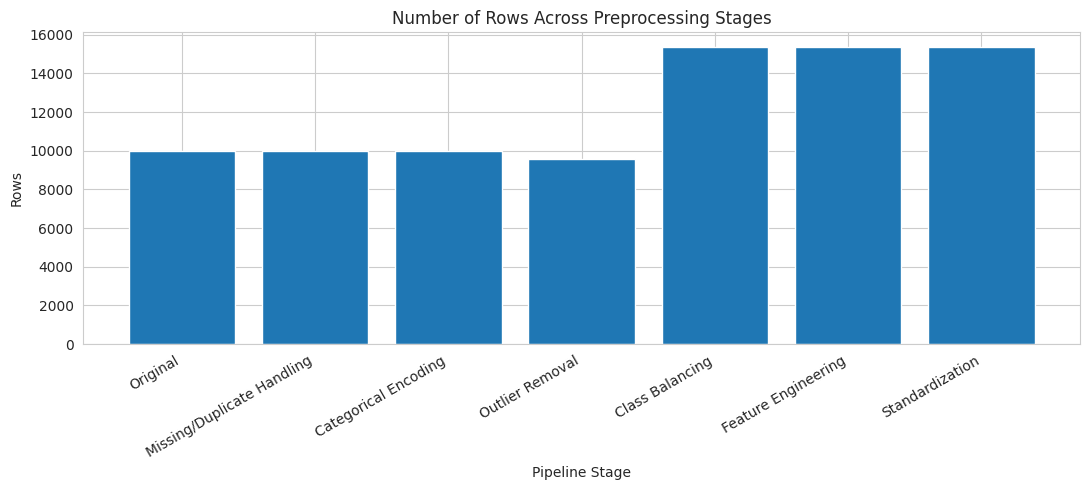

In [ ]:
# ============================================================
# 7B - Pipeline Stage Summary
# ============================================================

stage_summary = pd.DataFrame({
    "Stage": [
        "Original",
        "Missing/Duplicate Handling",
        "Categorical Encoding",
        "Outlier Removal",
        "Class Balancing",
        "Feature Engineering",
        "Standardization"
    ],

    "Rows": [
        df_original.shape[0],
        df_cleaned.shape[0],
        df_encoded.shape[0],
        df_outlier.shape[0],
        df_balanced.shape[0],
        df_featured.shape[0],
        df_final.shape[0]
    ],

    "Columns": [
        df_original.shape[1],
        df_cleaned.shape[1],
        df_encoded.shape[1],
        df_outlier.shape[1],
        df_balanced.shape[1],
        df_featured.shape[1],
        df_final.shape[1]
    ]
})

display(stage_summary)

plt.figure(figsize=(11, 5))

plt.bar(
    stage_summary["Stage"].astype(str),
    stage_summary["Rows"]
)

plt.title("Number of Rows Across Preprocessing Stages")
plt.xlabel("Pipeline Stage")
plt.ylabel("Rows")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()


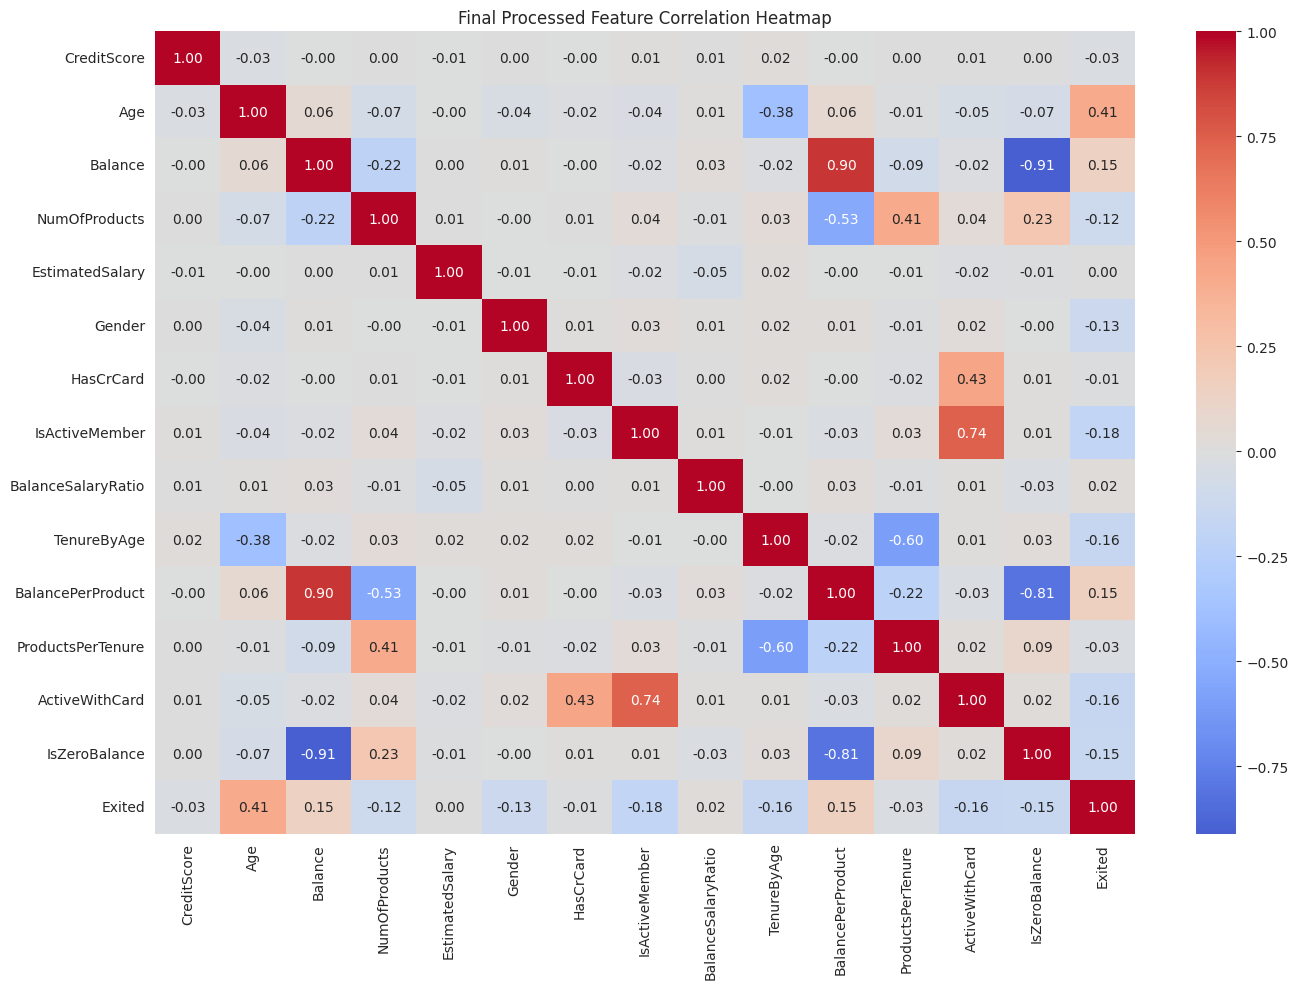

In [ ]:
# ============================================================
# 7C - Final Correlation Heatmap
# ============================================================

final_corr_features = [
    "CreditScore",
    "Age",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary",
    "Gender",
    "HasCrCard",
    "IsActiveMember",
    "BalanceSalaryRatio",
    "TenureByAge",
    "BalancePerProduct",
    "ProductsPerTenure",
    "ActiveWithCard",
    "IsZeroBalance",
    "Exited"
]

final_corr_features = [
    col for col in final_corr_features
    if col in df_final.columns
]

plt.figure(figsize=(14, 10))

sns.heatmap(
    df_final[
        final_corr_features
    ].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Final Processed Feature Correlation Heatmap"
)

plt.tight_layout()
plt.show()


# 8. Leakage-Safe Note for Final Model Training

The sequential pipeline above is useful for demonstrating how the six group preprocessing contributions connect.

For **final model evaluation**, two operations must be fitted using training data only:

1. **Class balancing** — oversample only the training set.
2. **Standardization** — fit `StandardScaler` only on the training set, then use the same fitted scaler to transform the test set.

This prevents test-set information from influencing training.


In [ ]:
# ============================================================
# 8A - Leakage-Safe Train/Test Demonstration
# ============================================================

# Use the data after encoding and outlier removal.
# Feature engineering is deterministic and does not use the target.

df_ml = df_outlier.copy()

# Create engineered features again
salary_safe = df_ml["EstimatedSalary"].replace(0, np.nan)
df_ml["BalanceSalaryRatio"] = (
    df_ml["Balance"] / salary_safe
).replace([np.inf, -np.inf], np.nan).fillna(0)

age_safe = df_ml["Age"].replace(0, np.nan)
df_ml["TenureByAge"] = (
    df_ml["Tenure"] / age_safe
).replace([np.inf, -np.inf], np.nan).fillna(0)

products_safe = df_ml["NumOfProducts"].replace(0, np.nan)
df_ml["BalancePerProduct"] = (
    df_ml["Balance"] / products_safe
).replace([np.inf, -np.inf], np.nan).fillna(0)

df_ml["ProductsPerTenure"] = (
    df_ml["NumOfProducts"] /
    (df_ml["Tenure"] + 1)
)

df_ml["ActiveWithCard"] = (
    df_ml["IsActiveMember"] *
    df_ml["HasCrCard"]
).astype(int)

df_ml["IsZeroBalance"] = (
    df_ml["Balance"] == 0
).astype(int)

X_ml = df_ml.drop(columns=["Exited"])
y_ml = df_ml["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X_ml,
    y_ml,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_ml
)

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)


Training shape: (7654, 17)
Testing shape : (1914, 17)


In [ ]:
# ============================================================
# 8B - Balance ONLY Training Data
# ============================================================

ros_safe = RandomOverSampler(
    random_state=RANDOM_STATE
)

X_train_balanced, y_train_balanced = (
    ros_safe.fit_resample(
        X_train,
        y_train
    )
)

print("Training classes BEFORE balancing:")
print(y_train.value_counts().sort_index())

print("\nTraining classes AFTER balancing:")
print(
    y_train_balanced
    .value_counts()
    .sort_index()
)

print("\nTest classes remain untouched:")
print(
    y_test
    .value_counts()
    .sort_index()
)


Training classes BEFORE balancing:
Exited
0    6141
1    1513
Name: count, dtype: int64

Training classes AFTER balancing:
Exited
0    6141
1    6141
Name: count, dtype: int64

Test classes remain untouched:
Exited
0    1536
1     378
Name: count, dtype: int64


In [ ]:
# ============================================================
# 8C - Fit StandardScaler ONLY on Training Data
# ============================================================

safe_scale_cols = [
    col for col in scale_cols
    if col in X_train_balanced.columns
]

safe_scaler = StandardScaler()

X_train_ready = X_train_balanced.copy()
X_test_ready = X_test.copy()

X_train_ready[safe_scale_cols] = (
    safe_scaler.fit_transform(
        X_train_balanced[safe_scale_cols]
    )
)

X_test_ready[safe_scale_cols] = (
    safe_scaler.transform(
        X_test[safe_scale_cols]
    )
)

print("Leakage-safe preprocessing completed.")

print("\nFinal training shape:", X_train_ready.shape)
print("Final testing shape :", X_test_ready.shape)


Leakage-safe preprocessing completed.

Final training shape: (12282, 17)
Final testing shape : (1914, 17)


# Combined Preprocessing Pipeline — Final Summary

The six individual preprocessing contributions have now been integrated into one churn preprocessing notebook.

### Integrated Contributions

- **Lathurshan**
  - Missing-value detection and handling
  - Duplicate-record detection and removal
  - Missing/duplicate EDA

- **Aathmika**
  - Removal of identifier columns
  - Binary encoding of `Gender`
  - One-Hot Encoding of `Geography`
  - Categorical EDA

- **Shakeer**
  - IQR-based outlier detection
  - Outlier-count analysis
  - Before/after boxplot visualization
  - Removal of detected outlier rows

- **Sipna**
  - Target class-distribution analysis
  - Imbalance-ratio calculation
  - Random Oversampling
  - Before/after class EDA

- **Thishan**
  - Six engineered predictors
  - Engineered-feature validation
  - Distribution and correlation EDA

- **Fatheen**
  - Skewness inspection
  - StandardScaler standardization
  - Before/after scaling EDA
  - Mean and standard-deviation validation

### Final Output

The final sequential group output is saved as:

`final_processed_churn_data.csv`

A leakage-safe train/test example is also included for the later model-training stage.


In [ ]:
# ============================================================
# SAVE FINAL GROUP OUTPUT
# ============================================================

output_file = "final_processed_churn_data.csv"

df_final.to_csv(
    output_file,
    index=False
)

print(
    "Final processed dataset saved successfully!"
)

print("File:", output_file)
print("Final shape:", df_final.shape)


Final processed dataset saved successfully!
File: final_processed_churn_data.csv
Final shape: (15354, 18)


In [ ]:
# ============================================================
# OPTIONAL: SAVE LEAKAGE-SAFE TRAIN/TEST OUTPUTS
# ============================================================

train_ready = X_train_ready.copy()
train_ready["Exited"] = y_train_balanced.values

test_ready = X_test_ready.copy()
test_ready["Exited"] = y_test.values

train_file = "final_train_processed.csv"
test_file = "final_test_processed.csv"

train_ready.to_csv(
    train_file,
    index=False
)

test_ready.to_csv(
    test_file,
    index=False
)

print("Saved:")
print("-", train_file)
print("-", test_file)


Saved:
- final_train_processed.csv
- final_test_processed.csv


In [ ]:
# ============================================================
# OPTIONAL GOOGLE COLAB DOWNLOAD
# ============================================================

try:
    from google.colab import files

    files.download(
        "final_processed_churn_data.csv"
    )

except ImportError:
    print(
        "Google Colab download is not available "
        "in this environment."
    )


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("final_processed_churn_data.csv")
files.download("final_train_processed.csv")
files.download("final_test__ processed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>